<a href="https://colab.research.google.com/github/peacewhile/PHM-Learning-Task/blob/main/NGAFID_DATASET_MINIROCKET_EXAMPLE5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/hyang0129/NGAFIDDATASET.git

!(cd NGAFIDDATASET ; git checkout main; git reset --hard HEAD; git pull)
!(cd NGAFIDDATASET ; pip install -r requirements.txt -q)

!pip install tsai -q

Cloning into 'NGAFIDDATASET'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 120 (delta 52), reused 64 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 253.61 KiB | 3.09 MiB/s, done.
Resolving deltas: 100% (52/52), done.
Already on 'main'
Your branch is up to date with 'origin/main'.
HEAD is now at fa72386 Update README.md
Already up to date.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 

In [2]:
!pip install --upgrade ipython -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.2/624.2 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.11.0 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [7]:
import sys
sys.path.append('/content/NGAFIDDATASET')

In [10]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
%autoreload
from tsai.basics import *
from tsai.models.MINIROCKET_Pytorch import *
from tsai.models.utils import *
import pandas as pd

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
!tar -xzf /content/drive/MyDrive/NGAFIDDATASET/2days.tar.gz -C /content/

In [13]:
import sys
sys.path.append('/content/NGAFIDDATASET')

import numpy as np
import pandas as pd
import pickle

# 手动构建一个简单的 dm 对象
class SimpleDM:
    pass

dm = SimpleDM()

# 注入元数据
dm.flight_header_df = pd.read_csv(
    '/content/2days/flight_header.csv',
    index_col='Master Index'
)

# 注入时序数据
with open('/content/2days/flight_data.pkl', 'rb') as f:
    dm.data_dict = pickle.load(f)

# 加载归一化参数
stats = pd.read_csv('/content/2days/stats.csv', index_col=0)
print(stats.head())
print(stats.shape)

   volt1  volt2   amp1  amp2  FQtyL  FQtyR  E1 FFlow  E1 OilT  E1 OilP  \
0   31.5   31.7   98.8  18.0   54.0   54.0    227.65    404.5   162.24   
1    0.0    0.0 -157.4  -5.6    0.0    0.0      0.00    -58.0   -14.55   

   E1 RPM  ...  E1 EGT2  E1 EGT3  E1 EGT4   OAT     IAS      VSpd  NormAc  \
0  3248.0  ...  1973.37  2003.87  2094.29  47.2  454.97  14160.48    2.92   
1     0.0  ...  -321.61  -336.31  -333.87 -57.2  -10.64 -32747.37   -2.41   

    AltMSL  timestep  cluster  
0  14744.4     30058      c_9  
1  -4324.1         0      c_1  

[2 rows x 25 columns]
(2, 25)


In [14]:
import numpy as np
stats_numeric = stats.drop(columns=['cluster'])
dm.mins = stats_numeric.loc[1].values.astype(np.float32)
dm.maxs = stats_numeric.loc[0].values.astype(np.float32)

In [15]:
import types

def get_numpy_dataset(self, fold, training):
    if training:
        mask = self.flight_header_df['fold'] != fold
    else:
        mask = self.flight_header_df['fold'] == fold
    subset = self.flight_header_df[mask]
    data = [self.data_dict[idx] for idx in subset.index]
    return {
        'data':         data,
        'target_class': subset['target_class'].values,
        'before_after': subset['before_after'].values,
        'fold':         subset['fold'].values
    }

dm.get_numpy_dataset = types.MethodType(get_numpy_dataset, dm)

In [16]:
from fastai.callback.progress import CSVLogger

from tqdm.autonotebook import tqdm

In [17]:
def pad_or_truncate(data_list, target_len=3000):
    result = []
    for arr in data_list:
        T = arr.shape[0]
        if T >= target_len:
            arr = arr[:target_len, :]
        else:
            pad = np.zeros((target_len - T, arr.shape[1]), dtype=np.float32)
            arr = np.concatenate([arr, pad], axis=0)
        result.append(arr)
    return np.array(result, dtype=np.float32).transpose(0, 2, 1)

  0%|          | 0/5 [00:00<?, ?it/s]

epoch,train_loss,valid_loss,accuracy,time
0,0.690287,0.688534,0.538865,00:03
1,0.686625,0.687023,0.551965,00:03
2,0.684070,0.685693,0.559389,00:07
3,0.683264,0.685291,0.563319,00:03
4,0.680873,0.685050,0.561572,00:03
5,0.681394,0.683014,0.558515,00:03
6,0.678940,0.683170,0.557205,00:04
7,0.677539,0.681968,0.560699,00:03
8,0.674372,0.680596,0.558952,00:03
9,0.675684,0.680130,0.567249,00:04


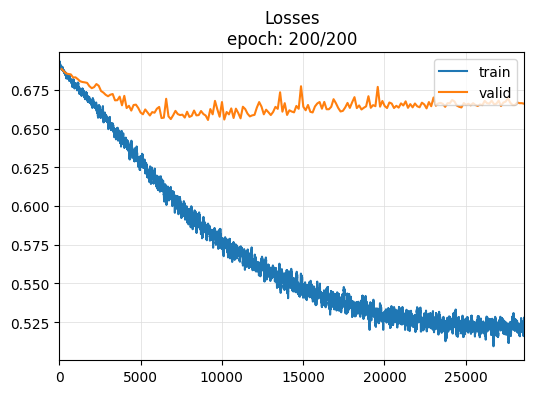

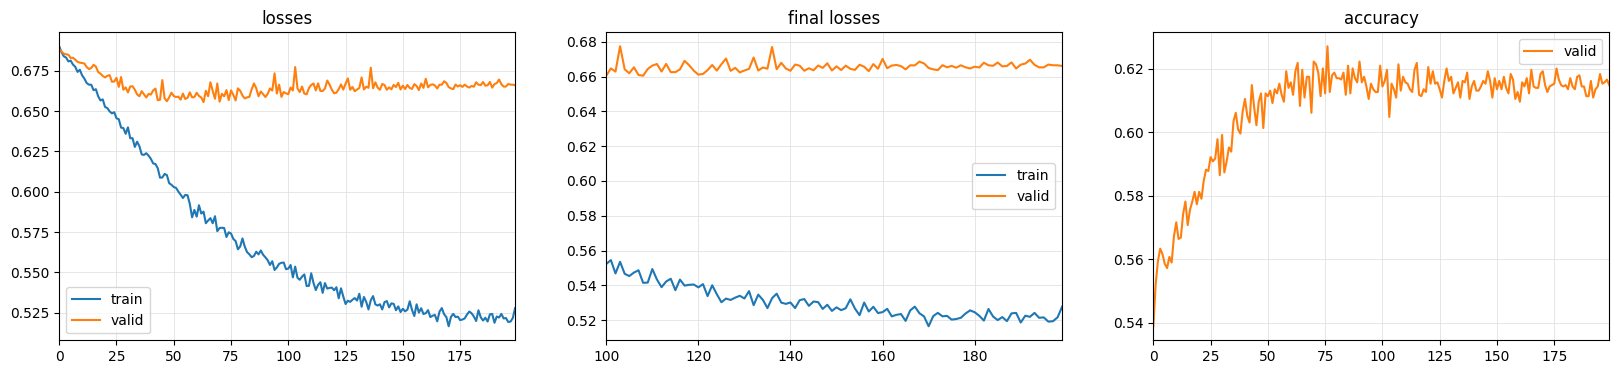

epoch,train_loss,valid_loss,accuracy,time
0,0.688450,0.688943,0.545216,00:04
1,0.686664,0.686999,0.557449,00:03
2,0.683922,0.685807,0.556575,00:04
3,0.683339,0.684785,0.555701,00:04
4,0.681152,0.683785,0.559196,00:03
5,0.678148,0.682749,0.558759,00:04
6,0.677674,0.682102,0.559196,00:04
7,0.677546,0.680941,0.560944,00:03
8,0.673793,0.681071,0.566186,00:03
9,0.672685,0.679886,0.569681,00:04


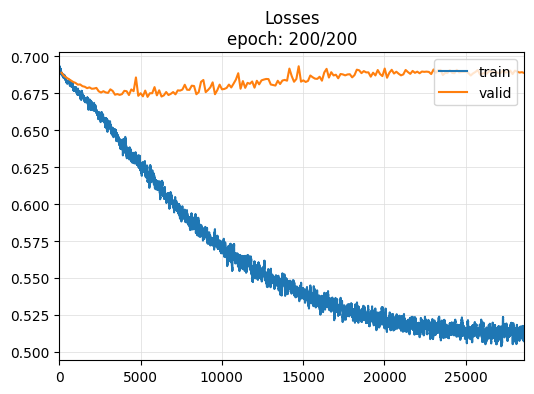

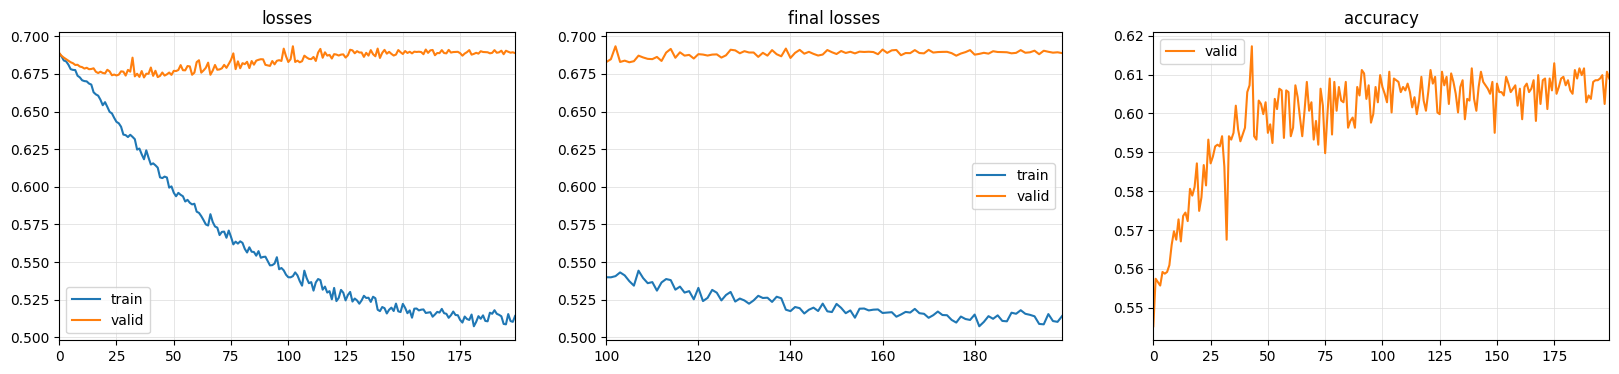

epoch,train_loss,valid_loss,accuracy,time
0,0.690485,0.687147,0.552643,00:04
1,0.688146,0.685009,0.563128,00:04
2,0.685544,0.683443,0.567934,00:03
3,0.683878,0.682046,0.572302,00:04
4,0.682035,0.680942,0.569681,00:04
5,0.679039,0.680215,0.571865,00:03
6,0.679110,0.679413,0.569244,00:03
7,0.678744,0.677781,0.567497,00:04
8,0.676722,0.677934,0.564439,00:03
9,0.676999,0.676150,0.565312,00:03


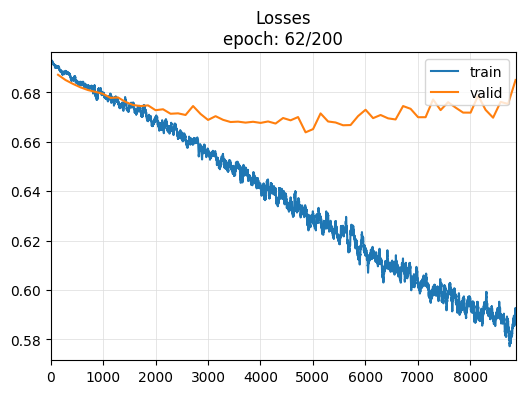

epoch,train_loss,valid_loss,accuracy,time
0,0.690485,0.687147,0.552643,00:04
1,0.688146,0.685009,0.563128,00:04
2,0.685544,0.683443,0.567934,00:03
3,0.683878,0.682046,0.572302,00:04
4,0.682035,0.680942,0.569681,00:04
5,0.679039,0.680215,0.571865,00:03
6,0.679110,0.679413,0.569244,00:03
7,0.678744,0.677781,0.567497,00:04
8,0.676722,0.677934,0.564439,00:03
9,0.676999,0.676150,0.565312,00:03


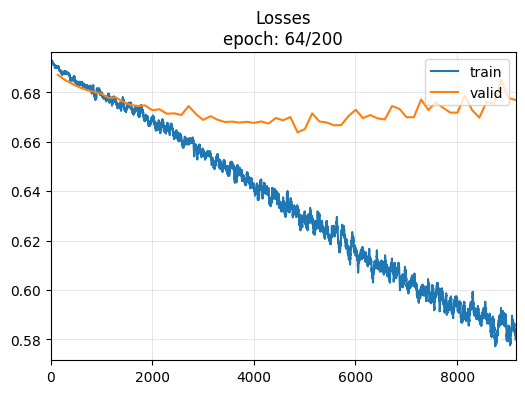

In [ ]:
import gc

save_path = '.'
model_name = 'MINIROCKET_BINARY'

mins23 = dm.mins[:23].reshape(-1, 1)
maxs23 = dm.maxs[:23].reshape(-1, 1)

for fold in tqdm(range(5)):

    save_filename = save_path + '%s_%i' % (model_name, fold)

    train_dict = dm.get_numpy_dataset(fold=fold, training=True)
    test_dict  = dm.get_numpy_dataset(fold=fold, training=False)

    train_X = pad_or_truncate(train_dict['data'], target_len=200)  # ← 改为200
    train_X = (train_X - mins23) / (maxs23 - mins23)
    train_X = np.nan_to_num(train_X, copy=False)

    test_X = pad_or_truncate(test_dict['data'], target_len=200)    # ← 改为200
    test_X = (test_X - mins23) / (maxs23 - mins23)
    test_X = np.nan_to_num(test_X, copy=False)

    train_Y = np.array(train_dict['before_after'])
    test_Y  = np.array(test_dict['before_after'])

    splits = [list(np.arange(len(train_Y)))]
    splits.append(list(np.arange(len(test_Y)) + len(train_Y)))

    torch.cuda.empty_cache()
    mrf = MiniRocketFeatures(train_X.shape[1], train_X.shape[2]).to(default_device())
    chunksize = 32                                                  # ← 从64改为32

    mrf.fit(train_X, chunksize=chunksize)

    X_feat = get_minirocket_features(np.concatenate([train_X, test_X]), mrf, chunksize=chunksize, to_np=True)

    Y = np.concatenate([train_Y, test_Y])

    PATH = Path("./models/MRF.pt")
    PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save(mrf.state_dict(), PATH)

    tfms = [None, TSClassification()]
    batch_tfms = TSStandardize(by_sample=True)
    dls = get_ts_dls(X_feat, Y, splits=splits, tfms=tfms, batch_tfms=batch_tfms)
    model = build_ts_model(MiniRocketHead, dls=dls)

    learn = Learner(dls, model, metrics=accuracy, cbs=[ShowGraph(), CSVLogger(save_filename)])

    results = learn.fit_one_cycle(200, 2.5e-5)

    # 每折结束后释放内存
    del train_X, test_X, X_feat, mrf, model, learn, dls, results
    torch.cuda.empty_cache()
    gc.collect()